In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics

pa_gs = pd.read_csv('data/pa_data.csv')
temps = pd.read_csv("data/pa_temps_supplement.csv")
pa_gs = pa_gs.merge(temps, on=["station_id", "year"], how="left")

pa_gs = pa_gs[pa_gs['year'] >= 1960]

### Summary Statistics for Annual Mean DTR

In [2]:
pa_gs_60_80 = pa_gs[pa_gs['year'].between(1960, 1980)]
pa_gs_80_00 = pa_gs[pa_gs['year'].between(1980,2000)]
pa_gs_00_23 = pa_gs[pa_gs['year'].between(2000,2023)]

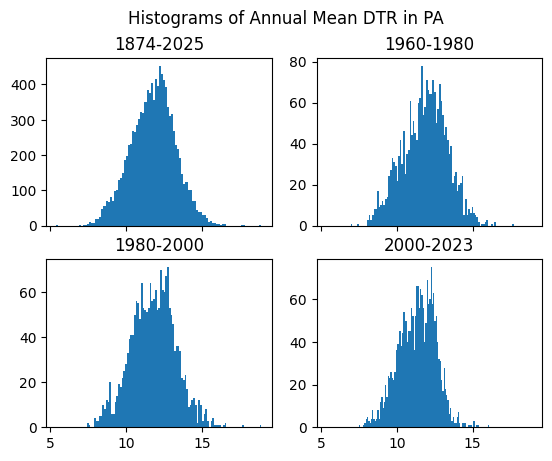

In [3]:
fig, axs = plt.subplots(2,2, sharex=True)
fig.suptitle("Histograms of Annual Mean DTR in PA")
axs[0,0].hist(pa_gs['dtr_annual'], bins = 100)
axs[0,0].set_title("1874-2025")
axs[0,1].hist(pa_gs_60_80['dtr_annual'], bins = 100)
axs[0,1].set_title("1960-1980")
axs[1,0].hist(pa_gs_80_00['dtr_annual'], bins = 100)
axs[1,0].set_title("1980-2000")
axs[1,1].hist(pa_gs_00_23['dtr_annual'], bins = 100)
axs[1,1].set_title("2000-2023")
plt.show()

In [4]:
pa_gs_60_80['dtr_annual'].describe()

count    2216.000000
mean       11.856683
std         1.473716
min         6.964110
25%        10.875087
50%        11.940767
75%        12.874710
max        17.719399
Name: dtr_annual, dtype: float64

In [5]:
pa_gs_80_00['dtr_annual'].describe()

count    2027.000000
mean       11.784631
std         1.491694
min         7.392350
25%        10.765255
50%        11.815512
75%        12.764805
max        18.899178
Name: dtr_annual, dtype: float64

In [6]:
pa_gs_00_23['dtr_annual'].describe()

count    2216.000000
mean       11.334990
std         1.214167
min         7.511045
25%        10.479206
50%        11.422696
75%        12.238602
max        16.075890
Name: dtr_annual, dtype: float64

In [7]:
print(statistics.variance(pa_gs_60_80['dtr_annual']))

2.1718392024771442


In [8]:
print(statistics.variance(pa_gs_80_00['dtr_annual']))

2.225151934625212


In [9]:
print(statistics.variance(pa_gs_00_23['dtr_annual']))

1.4742012350173272


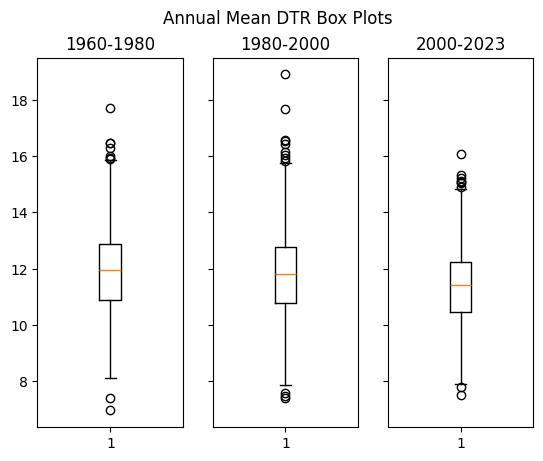

In [10]:
fig, axs = plt.subplots(1,3, sharey=True)
fig.suptitle('Annual Mean DTR Box Plots')
axs[0].boxplot(pa_gs_60_80['dtr_annual'])
axs[0].set_title("1960-1980")
axs[1].boxplot(pa_gs_80_00['dtr_annual'])
axs[1].set_title("1980-2000")
axs[2].boxplot(pa_gs_00_23['dtr_annual'])
axs[2].set_title("2000-2023")
plt.show()

### Basic Summary Statistic Analysis for Annual Mean Diurnal Temperature Range, PA

* Divided data up into 3 ~20 year chunks from 1960 to present
* Mean across all stations decreased in each interval, with a decrease of 0.07 deg C from 60-80 to 80-00 and a decrease of 0.45 deg C from 80-00 to 00-23
* IQR from 60-80 was 1.999, IQR from 80-00 was 2, and IQR from 00-23 was 1.759. Decrease in IQR was only found between 80-00 and 00-23, where IQR decreased by 0.241.
* Standard Deviations: std from 60-80 was 1.4737, std from 80-00 was 1.4917, and std from 00-23 was 1.2142. There was an increase of 0.018 from 60-80 to 80-00, and decrease of 0.2775 from 80-00 to 00-23
* Range from 60-80 was 10.755, from 80-00 was 11.507, and from 00-23 was 8.564.
* Variance from 60-80 was 2.1718, from 80-00 was 2.2252, and from 00-23 was 1.4742

### Box Plotting for Whole State / Subsets

In [36]:
pa_gs_80_95 = pa_gs[pa_gs['year'].between(1980, 1995)]
pa_gs_95_10 = pa_gs[pa_gs['year'].between(1995,2010)]
pa_gs_10_25 = pa_gs[pa_gs['year'].between(2010,2025)]

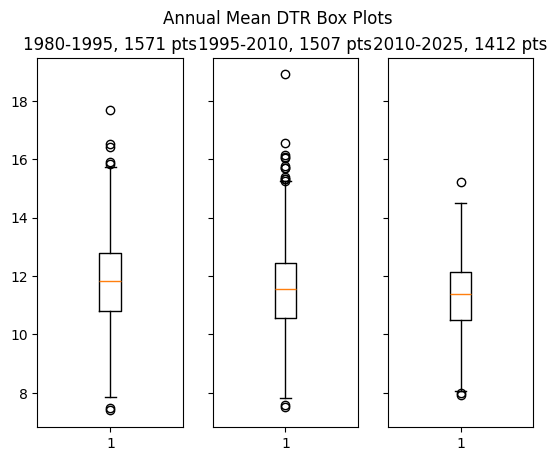

In [37]:
fig, axs = plt.subplots(1,3, sharey=True)
fig.suptitle('Annual Mean DTR Box Plots')
axs[0].boxplot(pa_gs_80_95['dtr_annual'])
axs[0].set_title(f"1980-1995, {len(pa_gs_80_95)} pts")
axs[1].boxplot(pa_gs_95_10['dtr_annual'])
axs[1].set_title(f"1995-2010, {len(pa_gs_95_10)} pts")
axs[2].boxplot(pa_gs_10_25['dtr_annual'])
axs[2].set_title(f"2010-2025, {len(pa_gs_10_25)} pts")
plt.show()

In [44]:
def data_intervals(data, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f, yr_int_3_s, yr_int_3_e):
    df1 = data[data['year'].between(yr_int_1_s, yr_int_1_e)]
    df2 = data[data['year'].between(yr_int_2_s, yr_int_2_f)]
    df3 = data[data['year'].between(yr_int_3_s, yr_int_3_e)]
    return df1, df2, df3

coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]
east_pa_stations = pa_gs[pa_gs['longitude'] < -77.569]
west_pa_stations = pa_gs[pa_gs['longitude'] > -77.569]
north_pa_stations = pa_gs[pa_gs['latitude'] > 40.58]
south_pa_stations = pa_gs[pa_gs['latitude'] < 40.58]
low_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] > 371.9]
high_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] <139.9]

subsets = {'Coastal': coastal_pa_stations, 'Inland': inland_pa_stations, 'Lakeside': lakeside_pa_stations, 
           'East': east_pa_stations, 'West': west_pa_stations, 'North': north_pa_stations,
           'South':south_pa_stations, 'Low Elevation':low_elevation_pa_stations, 'High Elevation': high_elevation_pa_stations}

def box_plot_subsets(data, data_name, variable, variable_name, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_e, yr_int_3_s, yr_int_3_e):
    df1, df2, df3 = data_intervals(data, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_e, yr_int_3_s, yr_int_3_e)

    fig, axs = plt.subplots(1,3, sharey=True)
    fig.suptitle(f'{data_name} {variable_name} Box Plots')
    axs[0].boxplot(df1[variable])
    axs[0].set_title(f'{yr_int_1_s}-{yr_int_1_e} ({len(df1)} pts)')
    axs[1].boxplot(df2[variable])
    axs[1].set_title(f'{yr_int_2_s}-{yr_int_2_e} ({len(df2)} pts)')
    axs[2].boxplot(df3[variable])
    axs[2].set_title(f'{yr_int_3_s}-{yr_int_3_e} ({len(df3)} pts)')
    plt.show()

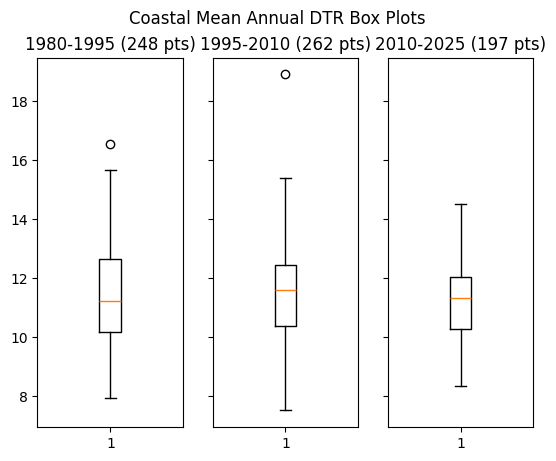

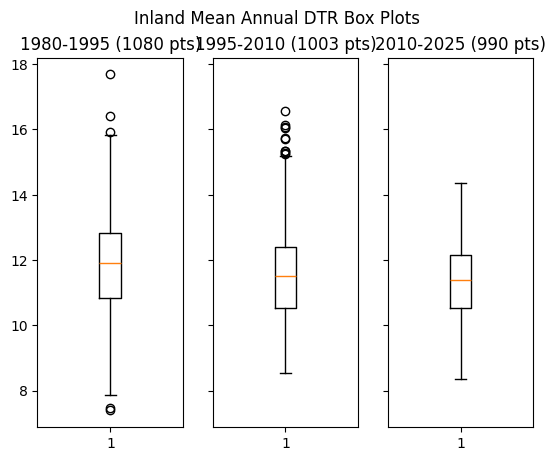

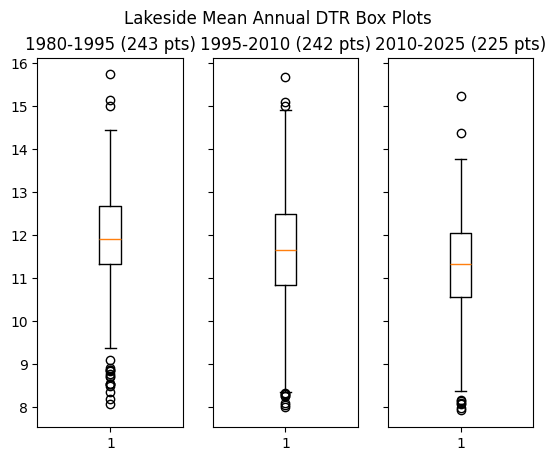

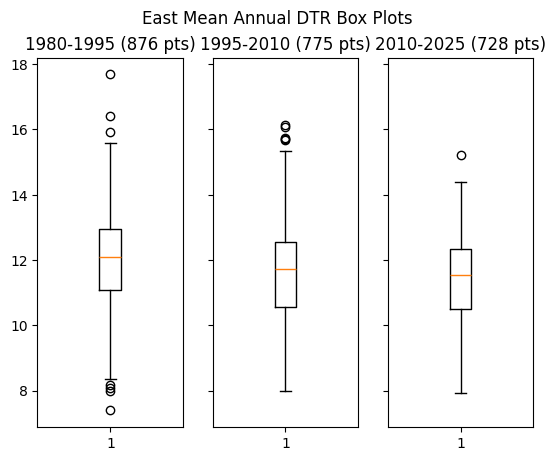

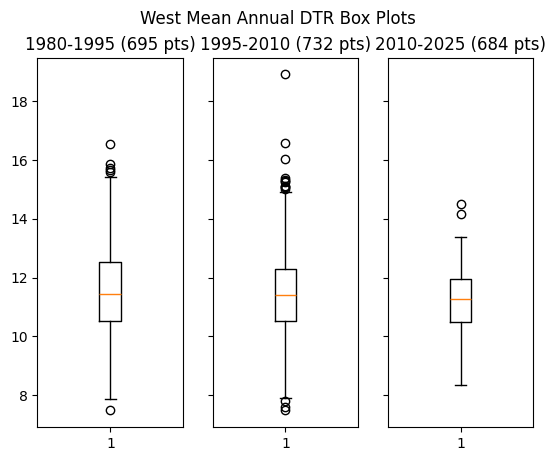

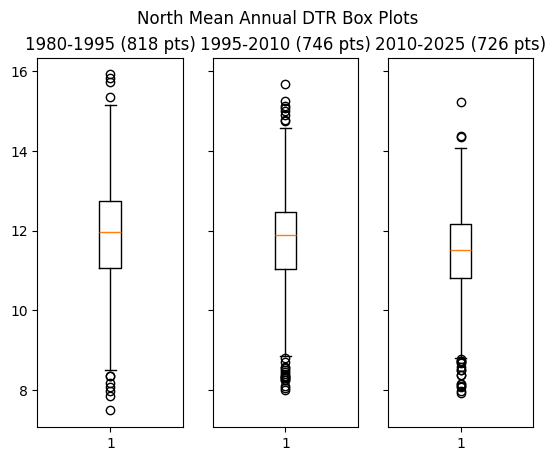

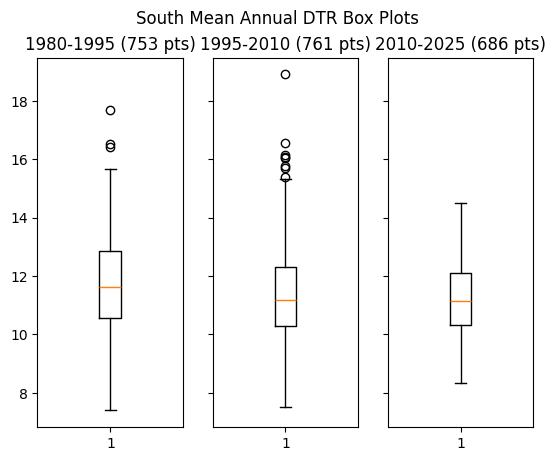

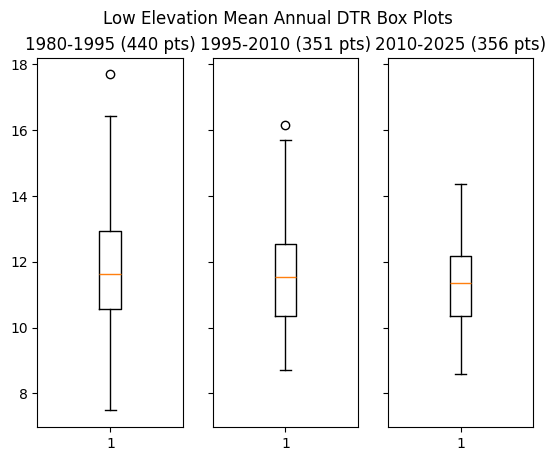

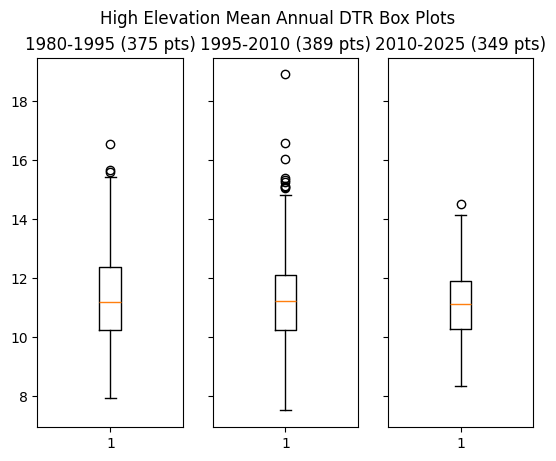

In [46]:
for subset_name, subset in subsets.items():
    box_plot_subsets(subset, subset_name, 'dtr_annual', 'Mean Annual DTR', 1980, 1995, 1995, 2010, 2010, 2025)

### Kruskal Wallis Test

In [15]:
from scipy import stats

In [16]:
def data_intervals(data, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f, yr_int_3_s, yr_int_3_e):
    df1 = data[data['year'].between(yr_int_1_s, yr_int_1_e)]
    df2 = data[data['year'].between(yr_int_2_s, yr_int_2_f)]
    df3 = data[data['year'].between(yr_int_3_s, yr_int_3_e)]
    return df1, df2, df3

def kruskal_wallis_test(data, variable, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f, yr_int_3_s, yr_int_3_e):

    df1, df2, df3 = data_intervals(data, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f, yr_int_3_s, yr_int_3_e)

    df1_array = df1[variable].values
    df2_array = df2[variable].values
    df3_array = df3[variable].values

    kw_test = stats.kruskal(df1_array, df2_array, df3_array)

    return kw_test

In [40]:
subsets = {'Coastal': coastal_pa_stations, 'Inland': inland_pa_stations, 'Lakeside': lakeside_pa_stations, 
           'East': east_pa_stations, 'West': west_pa_stations, 'North': north_pa_stations,
           'South':south_pa_stations, 'Low Elevation':low_elevation_pa_stations, 'High Elevation': high_elevation_pa_stations}

for subset_name, subset in subsets.items():
    kw_test = kruskal_wallis_test(subset, 'dtr_annual', 1980, 1995, 1995, 2010, 2010, 2025)
    print(f'{subset_name} : {kw_test}')

Coastal : KruskalResult(statistic=np.float64(3.0195419620950674), pvalue=np.float64(0.220960576324891))
Inland : KruskalResult(statistic=np.float64(84.39039601081676), pvalue=np.float64(4.729969534048183e-19))
Lakeside : KruskalResult(statistic=np.float64(28.629336025499885), pvalue=np.float64(6.070419045605255e-07))
East : KruskalResult(statistic=np.float64(79.48360321265085), pvalue=np.float64(5.49990086520279e-18))
West : KruskalResult(statistic=np.float64(20.287750573540137), pvalue=np.float64(3.9316145881888506e-05))
North : KruskalResult(statistic=np.float64(66.97575635195363), pvalue=np.float64(2.8602190675215536e-15))
South : KruskalResult(statistic=np.float64(42.28768215306868), pvalue=np.float64(6.566689691609228e-10))
Low Elevation : KruskalResult(statistic=np.float64(15.62347294908033), pvalue=np.float64(0.00040495424419349416))
High Elevation : KruskalResult(statistic=np.float64(3.359017742734722), pvalue=np.float64(0.18646553211648687))


Subsets with significant Kruskal-Wallis test results:
* Inland
* Lakeside
* East
* West
* North
* South
* Low Elevation

### F-Test for Variance Changes

In [18]:
def F_test_variance(data, variable, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f):

    grp1, grp2, grp3 = data_intervals(data, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f, 0, 0)

    var_1 = statistics.variance(grp1[variable])
    var_2 = statistics.variance(grp2[variable])

    f_value = var_1 / var_2

    deg_fr_1 = len(grp1) - 1
    deg_fr_2 = len(grp2) - 1

    p_value = stats.f.cdf(f_value, deg_fr_1, deg_fr_2)

    readout = f'Degree of freedom 1: {deg_fr_1}, Degree of freedom 2: {deg_fr_2}, F-statistic: {f_value}, p-value: {p_value}'
    return readout

In [19]:
F_test_variance(pa_gs, 'dtr_annual', 1980, 1995, 1995, 2010)

'Degree of freedom 1: 1570, Degree of freedom 2: 1506, F-statistic: 1.1011550575523346, p-value: 0.9704480743025687'

In [20]:
for subset_name, subset in subsets.items():
    f_test = F_test_variance(subset, 'dtr_annual', 1980, 1995, 1995, 2010)
    print(f'{subset_name} : {f_test}')

Coastal : Degree of freedom 1: 247, Degree of freedom 2: 261, F-statistic: 1.1307817387410537, p-value: 0.8363305791328823
Inland : Degree of freedom 1: 1079, Degree of freedom 2: 1002, F-statistic: 1.1924418283959002, p-value: 0.9976752571341442
Lakeside : Degree of freedom 1: 242, Degree of freedom 2: 241, F-statistic: 0.7497867476353596, p-value: 0.012817790114728334
East : Degree of freedom 1: 875, Degree of freedom 2: 774, F-statistic: 1.0305060954210445, p-value: 0.6660107989056654
West : Degree of freedom 1: 694, Degree of freedom 2: 731, F-statistic: 1.1338385960662418, p-value: 0.9531578682674777
North : Degree of freedom 1: 817, Degree of freedom 2: 745, F-statistic: 1.0659127308595477, p-value: 0.813020692366146
South : Degree of freedom 1: 752, Degree of freedom 2: 760, F-statistic: 1.1799308540863822, p-value: 0.9884875966912238
Low Elevation : Degree of freedom 1: 439, Degree of freedom 2: 350, F-statistic: 1.2610585695254841, p-value: 0.9884304953987705
High Elevation : 

In [41]:
for subset_name, subset in subsets.items():
    f_test = F_test_variance(subset, 'dtr_annual', 1995, 2010, 2010, 2025)
    print(f'{subset_name} : {f_test}')

Coastal : Degree of freedom 1: 261, Degree of freedom 2: 196, F-statistic: 1.8220981991450291, p-value: 0.9999941722300101
Inland : Degree of freedom 1: 1002, Degree of freedom 2: 989, F-statistic: 1.4659767274146733, p-value: 0.9999999990841935
Lakeside : Degree of freedom 1: 241, Degree of freedom 2: 224, F-statistic: 1.322136709158282, p-value: 0.9828556943694837
East : Degree of freedom 1: 774, Degree of freedom 2: 727, F-statistic: 1.3087281655049414, p-value: 0.9998791850469473
West : Degree of freedom 1: 731, Degree of freedom 2: 683, F-statistic: 1.849562853535005, p-value: 0.9999999999999997
North : Degree of freedom 1: 745, Degree of freedom 2: 725, F-statistic: 1.270624481843292, p-value: 0.999400855347332
South : Degree of freedom 1: 760, Degree of freedom 2: 685, F-statistic: 1.710956733221662, p-value: 0.9999999999994954
Low Elevation : Degree of freedom 1: 350, Degree of freedom 2: 355, F-statistic: 1.5202674903887199, p-value: 0.9999552385595076
High Elevation : Degree 

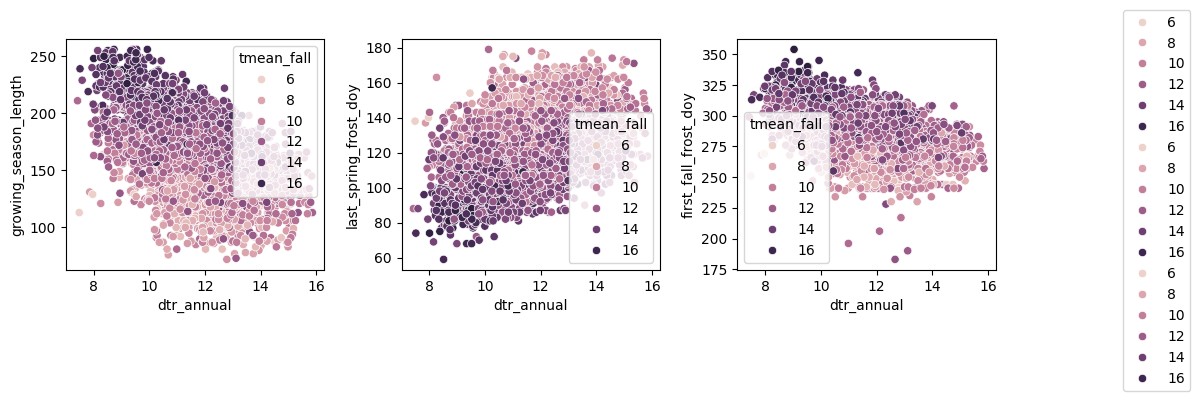

In [28]:
def outlier_remover(data, variables, number_std):
    for variable in variables:
        variable_std = data[variable].std()
        variable_mean = data[variable].mean()
        upper_limit = variable_mean + (variable_std * number_std)
        lower_limit = variable_mean - (variable_std * number_std)
        data = data[data[variable].between(lower_limit, upper_limit)]
    return data

pa_gs_outliers_removed = outlier_remover(pa_gs, ['dtr_annual', 'growing_season_length', 'tmean_fall'], 3)

fig, axs = plt.subplots(1,3, sharex=True, figsize = (12,3))
fig.subplots_adjust(wspace = 0.3)
sns.scatterplot(data = pa_gs_outliers_removed, x='dtr_annual', y='growing_season_length', hue='tmean_fall', ax=axs[0])
sns.scatterplot(data = pa_gs_outliers_removed, x='dtr_annual', y='last_spring_frost_doy', hue='tmean_fall', ax=axs[1])
sns.scatterplot(data = pa_gs_outliers_removed, x='dtr_annual', y='first_fall_frost_doy', hue='tmean_fall', ax=axs[2])
fig.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()